### Imports

In [ ]:
import numpy as np
import pandas as pd
import csv
import json
import argparse
from sklearn.metrics import accuracy_score
import graphviz
from sklearn.tree import export_graphviz
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier

import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import classification_report
pd.options.mode.chained_assignment = None
from sklearn.metrics import confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Definitions

In [ ]:
class_numbers = ['discord', 'whatsapp', 'signal', 'telegram', 'messenger', 'teams']
features = [' Min differential Packet Length', ' Max differential Packet Length', ' IAT min', ' IAT max', ' Packet Length Total']

In [ ]:
# Function to get scores of the model under test
def get_scores(classes, depth, n_tree, feats, max_leaf, X_train, y_train, X_test, y_test):

    model = RandomForestClassifier(max_depth=depth, n_estimators = n_tree, max_leaf_nodes=max_leaf, n_jobs=4,
                                    random_state=42, bootstrap=False, class_weight='balanced')
    model.fit(X_train[features], y_train)
    y_pred = model.predict(X_test[features])
    class_report = classification_report(y_test, y_pred, target_names=class_numbers, output_dict = True)
    macro_score = class_report['macro avg']['f1-score']
    weighted_score = class_report['weighted avg']['f1-score']

    return model, class_report, macro_score, weighted_score, y_pred

# Function to save final model for later analysis
def save_model(model, filename):
    pickle.dump(model, open(filename, 'wb'))

# Function to separate data into features and labels
def extract_x_y(Dataset, classes, features):
    Dataset = Dataset[Dataset["Label"].isin(class_numbers)]
    X = Dataset[features]
    y = Dataset['Label'].replace(class_numbers, range(len(class_numbers)))
    return X, y

# Function to Fit model based on optimal values of depth and number of estimators and use it
# to compute feature importance for all the features.
def get_feature_importance(depth, n_tree, max_leaf, X_train, y_train):
    rf_opt = RandomForestClassifier(max_depth = depth, n_estimators = n_tree,
                                    max_leaf_nodes=max_leaf, random_state=42, bootstrap=False, class_weight='balanced')
    rf_opt.fit(X_train, y_train)
    feature_importance = pd.DataFrame(rf_opt.feature_importances_)
    feature_importance.index = X_train.columns
    feature_importance = feature_importance.sort_values(by=list(feature_importance.columns),axis=0,ascending=False)

    return feature_importance

# Function to Fit model based on optimal values of depth and number of estimators and feature importance
# to find the fewest possible features to exceed the previously attained score with all selected features
def get_fewest_features(importance):
    sorted_feature_names = importance.index
    features = []
    for f in range(1,len(sorted_feature_names)+1):
        features.append(sorted_feature_names[0:f])
    return features

# Function to analyze different combinations of model hyperparameters
def analyze_models(class_numbers, model_type, depths, n_trees, X_train, y_train, X_test, y_test, max_leaf, filename_out):
    # Create a list to hold the results
    results = []

    if model_type == 'RF':
        # FOR EACH (depth, n_tree, feat)
        for depth in depths:
            for n_tree in n_trees:
                # get feature orders to use
                importance = get_feature_importance(depth, n_tree, max_leaf, X_train, y_train)
                print(importance)
                plt.figure(figsize=(10, 6))
                plt.barh(importance.index, importance[0])
                plt.gca().invert_yaxis()
                plt.title("Feature Importance in Random Forest")
                plt.xlabel("Importance Score")
                plt.ylabel("Feature")
                plt.tight_layout()
                plt.show()
                m_feats = get_fewest_features(importance)
                for feats in m_feats:
                    # Get the scores with the given (depth, n_tree, feat)
                    model, c_report, macro_f1, weight_f1, y_pred = get_scores(
                        class_numbers, depth, n_tree, feats, max_leaf, X_train, y_train, X_test, y_test
                    )

                    # Append results as a dictionary
                    results.append({
                        "depth": depth,
                        "n_tree": n_tree,
                        "max_leaf": max_leaf,
                        "n_feat": len(feats),
                        "macro": macro_f1,
                        "weighted": weight_f1,
                        "features": list(feats),  # Convert features to a list
                        "c_report": c_report  # Add the classification report
                    })

    # Write the results to a .json file
    with open(filename_out, mode="w") as file:
        json.dump(results, file, indent=4)  # Pretty-print JSON with an indentation of 4 spaces

    print("Analysis Complete. Check output file.")
    return []

def find_best_parameters(json_file, metric="weighted"):
    # Load the JSON file
    with open(json_file, 'r') as file:
        data = json.load(file)

    # Check if data is empty
    if not data:
        print("The JSON file is empty!")
        return None

    # Find the best configuration based on the specified metric
    best_config = max(data, key=lambda x: x[metric])

    # Print summary including depth
    print("Best Configuration:")
    print(f"Depth: {best_config['depth']}")
    print(f"N_tree: {best_config['n_tree']}")
    print(f"Max_leaf: {best_config['max_leaf']}")
    print(f"Number of Features: {best_config['n_feat']}")
    print(f"{metric.capitalize()} F1 Score: {best_config[metric]}")
    print(f"Features: {best_config['features']}")
    print(f"Classification Report: {best_config['c_report']}")

    return best_config

def evaluate_model_overfitting(model, X_train, y_train, X_test, y_test):
    # Evaluate training performance
    y_train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_report = classification_report(y_train, y_train_pred, output_dict=True)

    # Evaluate test performance
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_report = classification_report(y_test, y_test_pred, output_dict=True)

    # Analyze performance difference
    performance_diff = train_accuracy - test_accuracy
    if performance_diff > 0.1:  # Large gap between train and test
        evaluation = "The model is likely overfitting. Try regularization or simplifying the model."
    elif train_accuracy < 0.6 and test_accuracy < 0.6:  # Both low accuracies
        evaluation = "The model is likely underfitting. Try increasing complexity or adding more features."
    else:
        evaluation = "The model has a good balance between training and testing performance."

    # Print and return results
    results = {
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Train Report": train_report,
        "Test Report": test_report,
        "Evaluation": evaluation
    }

    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print(f"Performance Difference: {performance_diff}")
    print(f"Evaluation: {evaluation}")

    return results

# --- Plot Confusion Matrix as a Heatmap ---

def plot_confusion_matrix(conf_matrix, labels, save_path="confusion_matrix.png"):
    labels = ['Discord', 'WhatsApp', 'Signal', 'Telegram', 'Messenger', 'Teams']

    # Scale accuracy values to percentages
    conf_matrix = np.round(conf_matrix * 100, 2)

    plt.figure(figsize=(12, 10))
    plt.rcParams["font.family"] = "Quattrocento Sans"

    heatmap = sns.heatmap(
        conf_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={'size': 22}
    )

    plt.xlabel("Predicted (Classes)", fontsize=22)
    plt.ylabel("Actual (Classes)", fontsize=22)

    # Set tick label font sizes and align x labels to center under ticks
    plt.xticks(rotation=30, ha='center', fontsize=22)
    plt.yticks(rotation=0, fontsize=22)

    # Colorbar customization
    colorbar = heatmap.collections[0].colorbar
    colorbar.set_ticks([0, 20, 40, 60, 80, 100])
    colorbar.set_ticklabels(["0", "20", "40", "60", "80", "100"])
    colorbar.ax.tick_params(labelsize=22)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_metrics_bar_chart(accuracy, precision, recall, weighted_f1, macro_f1, save_path="metrics_plot.png"):
    metrics = ["Accuracy", "Precision", "Recall", "Weighted F1", "Macro F1"]
    scores = [accuracy, precision, recall, weighted_f1, macro_f1]

    font_size = 44  # Set the desired font size for all elements

    plt.figure(figsize=(24, 12))  # Increase width for better spacing
    bars = plt.bar(metrics, scores, color=["navy", "darkblue", "royalblue", "steelblue", "skyblue"])
    plt.ylim(60, 100)

    # Adding text annotations with specified font properties
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, score + 1, f"{score:.1f}",
                 ha="center", fontsize=font_size, fontfamily="Quattrocento Sans")

    # Apply font size to axis labels, title, and ticks
    plt.ylabel("Score [%]", fontsize=font_size, fontfamily="Quattrocento Sans")
    plt.xticks(fontsize=font_size, fontfamily="Quattrocento Sans")  # Rotate for spacing
    plt.yticks(fontsize=font_size, fontfamily="Quattrocento Sans")
    plt.title("Model Performance Metrics", fontsize=font_size, fontfamily="Quattrocento Sans")

    # Save the image
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Define ANSI escape code for #8F493F (approximate as a terminal color)
COLOR_CODE = "\033[38;2;143;73;63m"  # RGB escape sequence for the desired color
RESET_CODE = "\033[0m"  # Reset color

# --- Function to Compute TP, TN, FP, FN for Each Class ---
def compute_per_class_metrics(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    num_classes = conf_matrix.shape[0]  # Number of classes
    TP = np.diag(conf_matrix)  # True Positives
    FP = conf_matrix.sum(axis=0) - TP  # False Positives
    FN = conf_matrix.sum(axis=1) - TP  # False Negatives
    TN = conf_matrix.sum() - (FP + FN + TP)  # True Negatives

    return TP, TN, FP, FN

# --- Function to Display Per-Class Metrics with Color ---
def display_per_class_metrics(y_true, y_pred):
    labels = sorted(np.unique(y_true))  # Extract unique class labels
    TP, TN, FP, FN = compute_per_class_metrics(y_true, y_pred)

    print(f"\n{COLOR_CODE}=== Per-Class Confusion Metrics ==={RESET_CODE}")
    for i, label in enumerate(labels):
        print(f"{COLOR_CODE}Class {label}:{RESET_CODE}")
        print(f"{COLOR_CODE}  - TP: {TP[i]}, TN: {TN[i]}, FP: {FP[i]}, FN: {FN[i]}{RESET_CODE}")
        print(f"{COLOR_CODE}" + "-" * 40 + f"{RESET_CODE}")

# --- Function to Plot the Confusion Matrix for Each Class ---
def plot_per_class_metrics(y_true, y_pred):
    labels = sorted(np.unique(y_true))  # Extract unique class labels
    TP, TN, FP, FN = compute_per_class_metrics(y_true, y_pred)

    # Create subplots for each class
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # Adjust layout for 6 classes

    for idx, ax in enumerate(axes.flat):
        if idx >= len(labels):
            ax.axis("off")  # Hide extra subplots if classes are less than 6
            continue

        # Confusion Matrix for the class
        matrix = np.array([[f"TP\n{TP[idx]}", f"FP\n{FP[idx]}"],
                           [f"FN\n{FN[idx]}", f"TN\n{TN[idx]}"]])
        colors = np.array([[0, 1], [1, 0]])  # Blue for TP & TN, White for FP & FN

        # Heatmap with custom font properties
        sns.heatmap(colors, annot=matrix, fmt='', cmap="Blues", cbar=False,
                    xticklabels=["+", "-"], yticklabels=["+", "-"],
                    annot_kws={'size': 45, 'fontfamily': 'Quattrocento Sans'}, ax=ax)

        ax.set_xlabel("Actual Class", fontsize=40, fontname="Quattrocento Sans")
        ax.set_ylabel("Predicted Class", fontsize=40, fontname="Quattrocento Sans")
        ax.set_title(f"Class {labels[idx]}", fontsize=40, fontname="Quattrocento Sans")

    plt.tight_layout()
    plt.savefig("per_class_confusion_matrices.png", dpi=300, bbox_inches="tight")  # Save figure
    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Load input data

In [ ]:
train_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NIMS_IMA_train_data.csv")
train_data = train_data[train_data['Label'].isin(class_numbers)]
train_data.describe()

,Min Packet Length,Max Packet Length,Packet Length Total,Min differential Packet Length,Max differential Packet Length,IAT min,IAT max,Flow Duration
count,40405.000000,40405.000000,40405.000000,40405.000000,40405.000000,40405.000000,4.040500e+04,4.040500e+04
mean,68.156317,862.426729,2869.800198,49.495434,750.775993,394.945007,1.489010e+06,1.508087e+09
std,182.288446,539.144429,2688.604089,149.524954,511.324222,256.280577,1.735433e+07,1.744417e+10
min,40.000000,40.000000,320.000000,0.000000,0.000000,138.000000,3.320000e+02,1.742000e+06
25%,40.000000,344.000000,887.000000,0.000000,275.000000,298.000000,1.405000e+03,5.160000e+06
50%,40.000000,858.000000,1829.000000,0.000000,817.000000,319.000000,4.063000e+03,1.051400e+07
75%,40.000000,1480.000000,4152.000000,15.000000,1207.000000,379.000000,9.874000e+03,1.894200e+07
max,1480.000000,1500.000000,11840.000000,1378.000000,1460.000000,2776.000000,4.092485e+08,4.092543e+11


In [ ]:
test_data  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/NIMS_IMA_test_data.csv")
test_data = test_data[test_data['Label'].isin(class_numbers)]
test_data.describe()

,Min Packet Length,Max Packet Length,Packet Length Total,Min differential Packet Length,Max differential Packet Length,IAT min,IAT max,Flow Duration
count,13548.000000,13548.000000,13548.000000,13548.000000,13548.000000,13548.000000,1.354800e+04,1.354800e+04
mean,65.269634,873.171538,2846.412017,45.246531,765.271110,387.392309,7.614334e+04,8.556343e+07
std,169.172653,540.696432,2646.993971,136.959671,513.429326,251.113400,1.813118e+06,1.816991e+09
min,40.000000,40.000000,320.000000,0.000000,0.000000,138.000000,3.400000e+02,1.791000e+06
25%,40.000000,345.000000,897.000000,0.000000,286.000000,298.000000,1.499000e+03,5.194750e+06
50%,40.000000,875.000000,1864.000000,0.000000,817.000000,320.000000,3.730000e+03,1.013000e+07
75%,40.000000,1480.000000,4106.250000,16.000000,1256.000000,368.000000,9.773250e+03,1.867450e+07
max,1480.000000,1500.000000,11840.000000,1365.000000,1460.000000,3260.000000,9.344642e+07,9.347878e+10


In [ ]:
# Calculate the Pearson correlation matrix
numeric_data = train_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

In [ ]:
# Calculate the Pearson correlation matrix
numeric_data = test_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

### Segregating the data

In [ ]:
# Shuffle the data
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)


# split the data into train and test 75% and 25%
sm = SMOTE(random_state = 2)

### PCA function

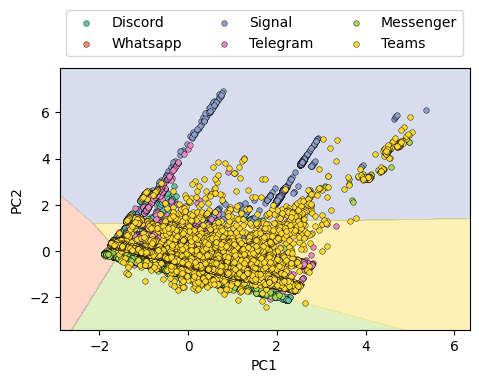

In [ ]:
# performing preprocessing part
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

X_train, y_train = extract_x_y(train_data, class_numbers, features)
X_test,  y_test  = extract_x_y(test_data, class_numbers, features)

# ==== Fit a visualization-only pipeline on TRAIN ====
viz_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("logreg", LogisticRegression(random_state=0, max_iter=1000))
])
viz_pipe.fit(X_train, y_train)

# Project TRAIN to 2D for plotting
X_train_2d = viz_pipe.named_steps["pca"].transform(
    viz_pipe.named_steps["scaler"].transform(X_train)
)

class_names = ["Discord", "Whatsapp", "Signal", "Telegram", "Messenger", "Teams"]

# Meshgrid in 2D PC space
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on grid (in 2D PC space)
Z = viz_pipe.named_steps["logreg"].predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Colors for 6 classes
cmap6 = ListedColormap(["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f"])
levels = np.arange(-0.5, 6.5, 1)
norm = BoundaryNorm(levels, cmap6.N)

# Decision regions + training points
plt.figure(figsize=(5,4))
plt.contourf(xx, yy, Z, levels=levels, cmap=cmap6, norm=norm, alpha=0.35)

for c in np.unique(y_train):
    m = (y_train == c)
    plt.scatter(X_train_2d[m, 0], X_train_2d[m, 1],
                s=16, edgecolor="k", linewidth=0.3,
                c=[cmap6(c)], label=class_names[c])

plt.rcParams.update({
    "font.size": 12,        # default text size
    "axes.titlesize": 10,   # title size
    "axes.labelsize": 10,   # x and y labels
    "xtick.labelsize": 10,  # x tick labels
    "ytick.labelsize": 10,  # y tick labels
})

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),  # just above the plot
    fontsize=10.1,
    framealpha=0.8,
    fancybox=True,
    ncol=3
)

# plt.title("Logistic Regression decision regions (TRAIN, PCA=2)")
plt.xlabel("PC1"); plt.ylabel("PC2")
# plt.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout();
plt.savefig("logistic_regression_decision_regions_train.pdf", bbox_inches="tight", dpi=700)
plt.show()

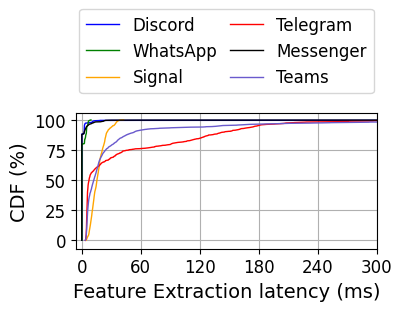

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
fig, axs = plt.subplots(1, 1, figsize=(3.5,2.00), gridspec_kw={'hspace': 0.2})

mpl.rcParams['font.size'] = 14
mpl.rcParams['lines.linewidth'] = 1.0

# Reload the CSV file after reset
df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ts_f_apps.csv")

# Assume the CSV has exactly 2 columns
col1_name = df.columns[0]
col2_name = df.columns[1]
col3_name = df.columns[2]
col4_name = df.columns[3]
col5_name = df.columns[4]
col6_name = df.columns[5]

col1_label = "Discord"
col2_label = "WhatsApp"
col3_label = "Signal"
col4_label = "Telegram"
col5_label = "Messenger"
col6_label = "Teams"

# Extract and sort both columns
col1_sorted_f = np.sort(df[col1_name].dropna().astype(int)) / 1000.0
col2_sorted_f = np.sort(df[col2_name].dropna().astype(int)) / 1000.0
col3_sorted_f = np.sort(df[col3_name].dropna().astype(int)) / 1000.0
col4_sorted_f = np.sort(df[col4_name].dropna().astype(int)) / 1000.0
col5_sorted_f = np.sort(df[col5_name].dropna().astype(int)) / 1000.0
col6_sorted_f = np.sort(df[col6_name].dropna().astype(int)) / 1000.0

# Compute CDFs (in percentage)
cdf1_f = np.arange(1, len(col1_sorted_f) + 1) / len(col1_sorted_f) * 100
cdf2_f = np.arange(1, len(col2_sorted_f) + 1) / len(col2_sorted_f) * 100
cdf3_f = np.arange(1, len(col3_sorted_f) + 1) / len(col3_sorted_f) * 100
cdf4_f = np.arange(1, len(col4_sorted_f) + 1) / len(col4_sorted_f) * 100
cdf5_f = np.arange(1, len(col5_sorted_f) + 1) / len(col5_sorted_f) * 100
cdf6_f = np.arange(1, len(col6_sorted_f) + 1) / len(col6_sorted_f) * 100

# Plot both CDFs
axs.plot(col1_sorted_f, cdf1_f, label=col1_label, color='blue')
axs.plot(col2_sorted_f, cdf2_f, label=col2_label, color='green')
axs.plot(col3_sorted_f, cdf3_f, label=col3_label, color='orange')
axs.plot(col4_sorted_f, cdf4_f, label=col4_label, color='red')
axs.plot(col5_sorted_f, cdf5_f, label=col5_label, color='black')
axs.plot(col6_sorted_f, cdf6_f, label=col6_label, color='#6A5ACD')
axs.set_xlim(0, 300)
axs.set_xticks(np.arange(0, 301, 60))
axs.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):d}"))  # integer ticks


axs.legend(
    loc='lower left',
    bbox_to_anchor=(0., 1.12, 1., 0.2),  # push higher
    ncol=2,
    mode="expand",
    borderaxespad=0.2,  # space between legend and axes
    fontsize=12,
    frameon=True,
    handlelength=2,
    columnspacing=2.5
)

axs.set_ylabel("CDF (%)", fontsize=14)
axs.grid(True)
axs.tick_params(axis='both', which='major', labelsize=12)
axs.set_yticks(np.arange(0, 101, 25))

# Add small visual gaps on both axes
xmin, xmax = axs.get_xlim()
ymin, ymax = axs.get_ylim()

axs.set_xlim(xmin - 0.02 * (xmax - xmin), xmax)  # 2% padding on left
axs.set_ylim(ymin - 2, ymax + 1)  # small padding below 0 and above top

axs.set_xlabel("Feature Extraction latency (ms)", fontsize=14)

axs.xaxis.get_offset_text().set_fontsize(10)

plt.subplots_adjust(left=0.12, right=0.98, bottom=0.22, top=0.9)
plt.savefig("feature_extraction_latency_cdf.pdf", bbox_inches="tight", dpi=700)
plt.show()

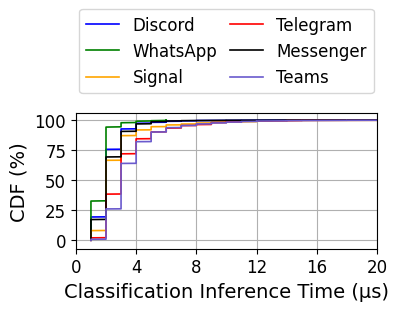

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
fig, axs = plt.subplots(1, 1, figsize=(3.5,2.00), gridspec_kw={'hspace': 0.2})

mpl.rcParams['font.size'] = 14
mpl.rcParams['lines.linewidth'] = 1.2

# Reload the CSV file after reset
df  = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ts_c_apps.csv")

# Assume the CSV has exactly 2 columns
col1_name = df.columns[0]
col2_name = df.columns[1]
col3_name = df.columns[2]
col4_name = df.columns[3]
col5_name = df.columns[4]
col6_name = df.columns[5]

# Extract and sort both columns
col1_sorted_c = np.sort(df[col1_name].dropna().astype(int))
col2_sorted_c = np.sort(df[col2_name].dropna().astype(int))
col3_sorted_c = np.sort(df[col3_name].dropna().astype(int))
col4_sorted_c = np.sort(df[col4_name].dropna().astype(int))
col5_sorted_c = np.sort(df[col5_name].dropna().astype(int))
col6_sorted_c = np.sort(df[col6_name].dropna().astype(int))

# Compute CDFs (in percentage)
cdf1_c = np.arange(1, len(col1_sorted_c) + 1) / len(col1_sorted_c) * 100
cdf2_c = np.arange(1, len(col2_sorted_c) + 1) / len(col2_sorted_c) * 100
cdf3_c = np.arange(1, len(col3_sorted_c) + 1) / len(col3_sorted_c) * 100
cdf4_c = np.arange(1, len(col4_sorted_c) + 1) / len(col4_sorted_c) * 100
cdf5_c = np.arange(1, len(col5_sorted_c) + 1) / len(col5_sorted_c) * 100
cdf6_c = np.arange(1, len(col6_sorted_c) + 1) / len(col6_sorted_c) * 100

# Plot both CDFs
axs.plot(col1_sorted_c, cdf1_c, label=col1_label, color='blue')
axs.plot(col2_sorted_c, cdf2_c, label=col2_label, color='green')
axs.plot(col3_sorted_c, cdf3_c, label=col3_label, color='orange')
axs.plot(col4_sorted_c, cdf4_c, label=col4_label, color='red')
axs.plot(col5_sorted_c, cdf5_c, label=col5_label, color='black')
axs.plot(col6_sorted_c, cdf6_c, label=col6_label, color='#6A5ACD')
axs.set_xlim(0, 20)


axs.legend(
    loc='lower left',
    bbox_to_anchor=(0., 1.12, 1., 0.2),  # push higher
    ncol=2,
    mode="expand",
    borderaxespad=0.2,  # space between legend and axes
    fontsize=12,
    frameon=True,
    handlelength=2,
    columnspacing=2.5
)

axs.set_ylabel("CDF (%)", fontsize=14)
axs.grid(True)
axs.tick_params(axis='both', which='major', labelsize=12)
axs.set_yticks(np.arange(0, 101, 25))

# Add small visual gaps on both axes
xmin, xmax = axs.get_xlim()
ymin, ymax = axs.get_ylim()

axs.set_xlim(xmin - 0.02 * (xmax - xmin), xmax)
axs.set_ylim(ymin - 2, ymax + 1)
axs.set_xlim(0, 20)
axs.set_xticks(np.arange(0, 20.1, 4))

axs.set_xlabel("Classification Inference Time (µs)", fontsize=14)

axs.xaxis.get_offset_text().set_fontsize(8)

plt.subplots_adjust(left=0.12, right=0.98, bottom=0.22, top=0.9)
plt.savefig("classification_inference_cdf.pdf", bbox_inches="tight", dpi=700)
plt.show()

In [ ]:
print("Classes present in background:", np.unique(Z))
print("All class ids:", np.unique(y_set))


Classes present in background: [0 1 2 4 5]
All class ids: [0 1 2 3 4 5]


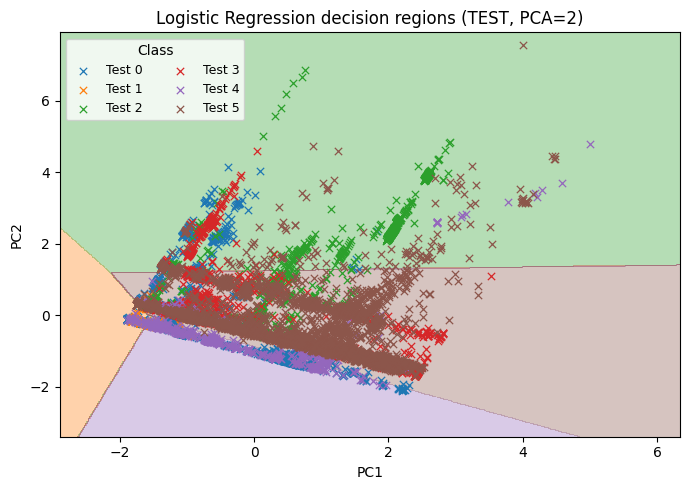

In [ ]:
# performing preprocessing part
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

X_train, y_train = extract_x_y(train_data, class_numbers, features)
X_test,  y_test  = extract_x_y(test_data, class_numbers, features)

# ==== Fit the SAME visualization pipeline on TRAIN (again here for self-contained code) ====
viz_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("logreg", LogisticRegression(random_state=0, max_iter=1000))
])
viz_pipe.fit(X_train, y_train)

# Project TRAIN and TEST to the same 2D PC space
X_train_2d = viz_pipe.named_steps["pca"].transform(
    viz_pipe.named_steps["scaler"].transform(X_train)
)
X_test_2d = viz_pipe.named_steps["pca"].transform(
    viz_pipe.named_steps["scaler"].transform(X_test)
)

# Meshgrid based on TRAIN 2D span (keeps regions consistent)
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on grid (2D PC space)
Z = viz_pipe.named_steps["logreg"].predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Colors for 6 classes
cmap6 = ListedColormap(["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b"])
levels = np.arange(-0.5, 6.5, 1)
norm = BoundaryNorm(levels, cmap6.N)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, levels=levels, cmap=cmap6, norm=norm, alpha=0.35)

# Plot TEST points with a different marker to distinguish
for c in np.unique(y_test):
    m = (y_test == c)
    plt.scatter(X_test_2d[m, 0], X_test_2d[m, 1],
                s=28, marker="x", linewidth=0.9,
                c=[cmap6(c)], label=f"Test {c}")

plt.title("Logistic Regression decision regions (TEST, PCA=2)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Class", fontsize=9, ncol=2)
plt.tight_layout(); plt.show()


In [ ]:
# Shuffle the data
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

# split the data into train and test 75% and 25%
sm = SMOTE(random_state = 2)

### Feature engineering

In [ ]:
features_t = [' Min differential Packet Length', ' Max differential Packet Length', ' IAT min', ' IAT max', ' Packet Length Total']

In [ ]:
X_train, y_train = extract_x_y(train_data, class_numbers, features_t)

X_test,  y_test  = extract_x_y(test_data, class_numbers, features_t)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train.ravel())
X_test_res, y_test_res = sm.fit_resample(X_test, y_test.ravel())



In [ ]:
# Confirm scores of selected model
model = RandomForestClassifier(criterion="gini", max_depth=20, n_estimators = 3, max_leaf_nodes=64, n_jobs=4, random_state=42, bootstrap=False)

model.fit(X_train_res[features_t], y_train_res)

# Evaluate the model
evaluate_model_overfitting(model, X_train_res, y_train_res, X_test, y_test)

y_pred = model.predict(X_test[features_t])

y_true = y_test

y_scores = model.predict_proba(X_test)

class_report = classification_report(y_test, y_pred, target_names=class_numbers, output_dict = True)

print(classification_report)

macro_score = class_report['macro avg']['f1-score']
weighted_score = class_report['weighted avg']['f1-score']

print("Macro Score: ", macro_score)
print("Weighted Score: ", weighted_score)

df = pd.DataFrame(class_report).transpose()

df

Train Accuracy: 0.897848821026681
Test Accuracy: 0.8697962798937112
Performance Difference: 0.028052541132969733
Evaluation: The model has a good balance between training and testing performance.
<function classification_report at 0x7c826990ade0>
Macro Score:  0.862321950591774
Weighted Score:  0.8726464531748237


,precision,recall,f1-score,support
discord,0.870351,0.900107,0.884979,1872.000000
whatsapp,0.805792,0.973251,0.881640,486.000000
signal,0.973572,0.900873,0.935813,2290.000000
telegram,0.656759,0.855703,0.743147,1885.000000
messenger,0.930645,0.750325,0.830814,1538.000000
teams,0.920537,0.875662,0.897539,5477.000000
accuracy,0.869796,0.869796,0.869796,0.869796
macro avg,0.859610,0.875987,0.862322,13548.000000
weighted avg,0.882898,0.869796,0.872646,13548.000000


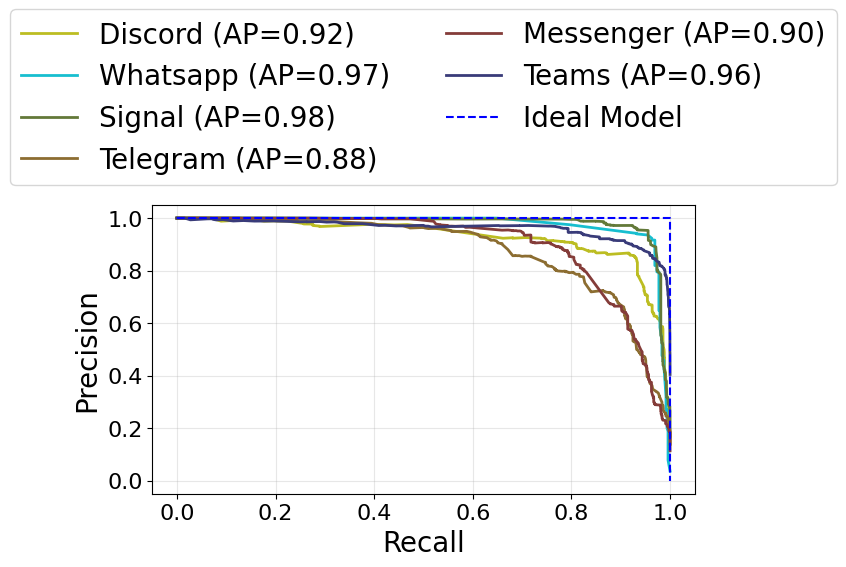

In [ ]:
# Binarize the labels (one-vs-rest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

class_names = ["Discord", "Whatsapp", "Signal", "Telegram", "Messenger", "Teams"]

# Ensure classes are numeric indices (0..N-1)
classes = np.arange(len(class_names))
y_true_bin = label_binarize(y_true, classes=classes)
n_classes = y_true_bin.shape[1]

# Define the custom color map
color_map = {
        "Discord": "#bcbd22",
        "Whatsapp": "#17becf",
        "Teams": "#393b79",
        "Signal": "#637939",
        "Telegram": "#8c6d31",
        "Messenger": "#843c39"
}

# Plot PR curve per class
plt.figure(figsize=(7,3.75))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_scores[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_scores[:, i])
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]} (AP={ap:.2f})", color=color_map[class_names[i]])

# Ideal model reference line (┐ shape)
plt.plot([0, 1, 1], [1, 1, 0], color="blue", linestyle="--", label="Ideal Model")

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),  # just above the plot
    fontsize=20,
    framealpha=0.8,
    fancybox=True,
    ncol=2
)


plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 20,   # title size
    "axes.labelsize": 20,   # x and y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
})

plt.grid(alpha=0.3)
plt.savefig("pr_curves_RF_messaging_apps.pdf", bbox_inches="tight")

plt.show()

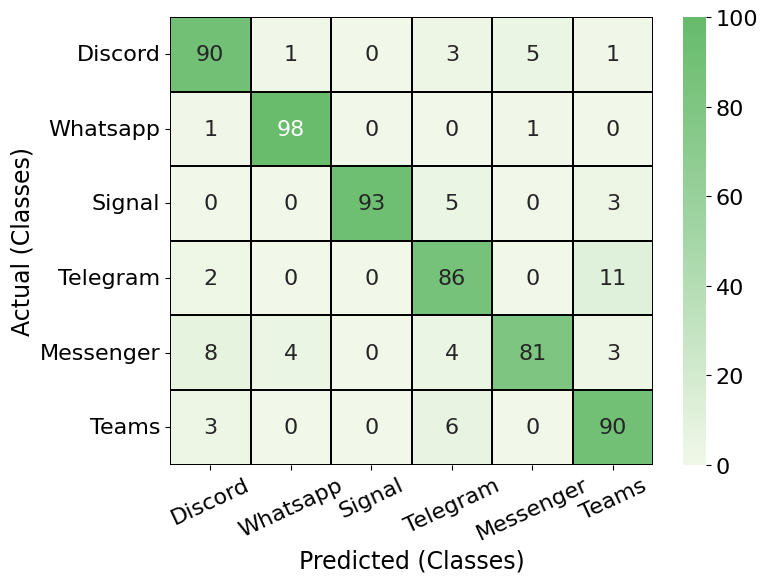

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm

# Confusion matrix data
conf_matrix = np.array([
    [90, 1, 0, 3, 5, 1],
    [1, 98, 0, 0, 1, 0],
    [0, 0, 93, 5, 0, 3],
    [2, 0, 0, 86, 0, 11],
    [8, 4, 0, 4, 81, 3],
    [3, 0, 0, 6, 0, 90]
])

pale_green = LinearSegmentedColormap.from_list(
    'pale_green', ['#f1f8e9', '#a5d6a7', '#66bb6a']  # lightest to mid green
)

# ["#8F493F", "#82AA45"]

plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',  # integers only
    cmap=pale_green,
    cbar=True,
    xticklabels=["Discord", "Whatsapp", "Signal", "Telegram", "Messenger", "Teams"],
    yticklabels=["Discord", "Whatsapp", "Signal", "Telegram", "Messenger", "Teams"],
    linewidths=0.3,
    linecolor='black',
    vmin=0, vmax=100,
    annot_kws={"size": 16, "ha": "center", "va": "center"}  # no bold
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
plt.xlabel("Predicted (Classes)", fontsize=17)
plt.ylabel("Actual (Classes)", fontsize=17)

plt.xticks(rotation=0, fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.xticks(rotation=25)

plt.tight_layout()
plt.savefig("heatmap.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()





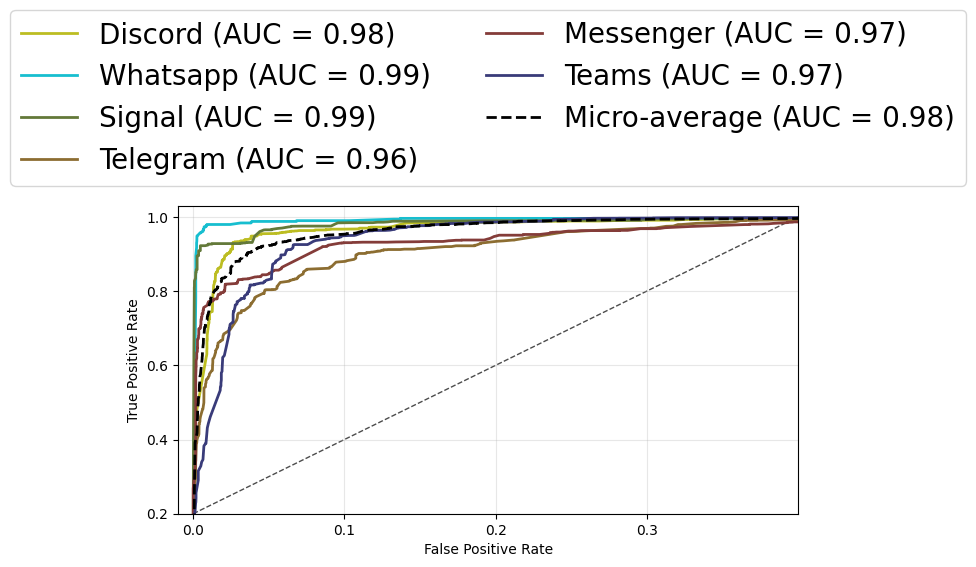

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

plt.figure(figsize=(8,4))

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_numbers)))
n_classes = y_test_bin.shape[1]

class_names = ["Discord", "Whatsapp", "Signal", "Telegram", "Messenger", "Teams"]

# Define the custom color map
color_map = {
        "Discord": "#bcbd22",
        "Whatsapp": "#17becf",
        "Teams": "#393b79",
        "Signal": "#637939",
        "Telegram": "#8c6d31",
        "Messenger": "#843c39"
}

# Get prediction probabilities
y_score = model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves


# Diagonal line
plt.plot([0.0, 0.4], [0.2, 1.0], 'k--', lw=1, alpha=0.7, zorder=0)

# Add grid with minor ticks
# plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.grid(alpha=0.3)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})", color=color_map[class_names[i]])

# Micro-average curve
plt.plot(fpr["micro"], tpr["micro"], color="black", linestyle="--",
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})", lw=2)


# Axis settings
plt.xlim([-0.01, 0.4])   # Only show FPR up to 0.4
plt.ylim([0.6, 1.03])  # Zoom into TPR between 0.6 and 1.0

# Minor ticks within reduced range
plt.xticks(np.arange(0, 0.4, 0.1))
plt.yticks(np.arange(0.2, 1.05, 0.2))

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# Legend formatting (no border box)
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),  # just above the plot
    fontsize=20,
    framealpha=0.8,
    fancybox=True,
    ncol=2
)


plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 20,   # title size
    "axes.labelsize": 20,   # x and y labels
    "xtick.labelsize": 16,  # x tick labels
    "ytick.labelsize": 16,  # y tick labels
})

# Save and show
plt.savefig("roc_curve_RF_messaging_apps.pdf", bbox_inches="tight")
plt.show()

### Save the model

In [ ]:
save_model(model, "messaging_apps_classification.pkl")